# Explication des données éléctorales par arbre

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from functools import reduce
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import shap
from tqdm import tqdm

## Explication du vote Emmanuel Macron versus Le Pen au second tour de l'éléection présidentielle de 2022

Pour essaye de prédir si une commune a placé Emmanuel Macron en tête au premier tour.

On se base sur les critères explicatifs suivants :
- Taille de la commune
- Niveau de revenu
- Age moyen
- Taux d'alphabetisation
- Niveau de diplôme
- Catégorie socio-professionnelle

Préparation des données

In [4]:
# Function to load a CSV in chunks with a progress bar
def load_csv_with_progress(filepath):
    """Loads a Parquet file into a Pandas DataFrame."""
    try:
        df = pd.read_parquet(filepath)
        print(f"Data loaded successfully from {filepath}")
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

In [9]:
# Function to load a CSV in chunks with a progress bar
def load_csv_with_progress_csv(filepath, chunksize=10000):
    # Read the CSV in chunks and show a progress bar
    chunks = pd.read_csv(filepath, low_memory=False, iterator=True, chunksize=chunksize)
    return pd.concat(
        [chunk for chunk in tqdm(chunks, desc=f"Loading {filepath.split('/')[-1]}")]
    )

In [6]:
# Load each dataset with a progress bar
taille_commune = load_csv_with_progress(
    "data/Taille_agglo_commune_csv/popcommunes.parquet"
)
pib = load_csv_with_progress("data/Revenus_csv/pibcommunes.parquet")
age_data = load_csv_with_progress("data/Age_csp/agesexcommunes.parquet")
literacy_data = load_csv_with_progress("data/alphabetisationcommunes.parquet")
education_data = load_csv_with_progress("data/Diplomes_csv/diplomescommunes.parquet")
socio_prof_data = load_csv_with_progress("data/CSP_csv/cspcommunes.parquet")
delinquence = load_csv_with_progress("data/CSP_csv/crimesdelitscommunes.parquet")
ens_prive = load_csv_with_progress(
    "data/Enseignement_prive_csv/publicprivecommunes2021.parquet"
)
capital_immo = load_csv_with_progress(
    "data/Capital_immobilier_csv/capitalimmobiliercommunes.parquet"
)
menage_data = load_csv_with_progress("data/Age_csp/menagescommunes.parquet")
immigration_data = load_csv_with_progress(
    "data/Nationalites_csv/etrangerscommunes.parquet"
)
owner_data = load_csv_with_progress(
    "data/Proprietaires_csv/proprietairescommunes.parquet"
)
revenus = load_csv_with_progress("data/Revenus_csv/revcommunes.parquet")

Data loaded successfully from data/Taille_agglo_commune_csv/popcommunes.parquet
Data loaded successfully from data/Revenus_csv/pibcommunes.parquet
Data loaded successfully from data/Age_csp/agesexcommunes.parquet
Data loaded successfully from data/alphabetisationcommunes.parquet
Data loaded successfully from data/Diplomes_csv/diplomescommunes.parquet
Data loaded successfully from data/CSP_csv/cspcommunes.parquet
Data loaded successfully from data/CSP_csv/crimesdelitscommunes.parquet
Data loaded successfully from data/Enseignement_prive_csv/publicprivecommunes2021.parquet
Data loaded successfully from data/Capital_immobilier_csv/capitalimmobiliercommunes.parquet
Data loaded successfully from data/Age_csp/menagescommunes.parquet
Data loaded successfully from data/Nationalites_csv/etrangerscommunes.parquet
Data loaded successfully from data/Proprietaires_csv/proprietairescommunes.parquet
Data loaded successfully from data/Revenus_csv/revcommunes.parquet


In [1]:
pres2022 = load_csv_with_progress("data/elections/pres2022_csv/pres2022comm.parquet")
pres2017 = load_csv_with_progress("data/elections/pres2017_csv/pres2017comm.parquet")

NameError: name 'load_csv_with_progress' is not defined

In [12]:
dataframes = {
    "Taille Commune": taille_commune,
    "PIB": pib,
    "Age Data": age_data,
    "Literacy Data": literacy_data,
    "Education Data": education_data,
    "Socio-Professional Data": socio_prof_data,
    "Delinquence": delinquence,
    "Private Education": ens_prive,
    "Real Estate Capital": capital_immo,
    "Household Data": menage_data,
    "Immigration Data": immigration_data,
    "Owner Data": owner_data,
    "Revenue Data": revenus,
}


# Function to summarize each DataFrame
def summarize_dataframe(df, name):
    print(f"--- Summary for {name} ---")
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nStatistical Summary:\n", df.describe(include="all"))
    print("-" * 40)

Loading menagescommunes.csv: 4it [00:00, 13.78it/s]


In [10]:
# Summarize each DataFrame
for name, df in dataframes.items():
    summarize_dataframe(df, name)

--- Summary for Taille Commune ---

Shape: (34856, 983)

Columns: ['dep', 'nomdep', 'codecommune', 'nomcommune', 'paris', 'reg', 'nomreg', 'codeagglo', 'nomagglo', 'multicommune', 'numcommune', 'popagglo1780', 'popagglo1781', 'popagglo1782', 'popagglo1783', 'popagglo1784', 'popagglo1785', 'popagglo1786', 'popagglo1787', 'popagglo1788', 'popagglo1789', 'popagglo1790', 'popagglo1791', 'popagglo1792', 'popagglo1793', 'popagglo1794', 'popagglo1795', 'popagglo1796', 'popagglo1797', 'popagglo1798', 'popagglo1799', 'popagglo1800', 'popagglo1801', 'popagglo1802', 'popagglo1803', 'popagglo1804', 'popagglo1805', 'popagglo1806', 'popagglo1807', 'popagglo1808', 'popagglo1809', 'popagglo1810', 'popagglo1811', 'popagglo1812', 'popagglo1813', 'popagglo1814', 'popagglo1815', 'popagglo1816', 'popagglo1817', 'popagglo1818', 'popagglo1819', 'popagglo1820', 'popagglo1821', 'popagglo1822', 'popagglo1823', 'popagglo1824', 'popagglo1825', 'popagglo1826', 'popagglo1827', 'popagglo1828', 'popagglo1829', 'popag

In [79]:
feature_1 = taille_commune[["codecommune", "pop2022"]]
feature_2 = pib[["codecommune", "pibratio2022"]]
feature_3 = age_data[["codecommune", "age2022"]]
feature_4 = age_data[["codecommune", "age2017"]]
feature_5 = education_data[["codecommune", "bach2022"]]
feature_6 = socio_prof_data[["codecommune", "agri2022"]]
feature_7 = socio_prof_data[["codecommune", "indp2022"]]
feature_8 = socio_prof_data[["codecommune", "cadr2022"]]
feature_9 = socio_prof_data[["codecommune", "pint2022"]]
feature_10 = socio_prof_data[["codecommune", "empl2022"]]
feature_11 = socio_prof_data[["codecommune", "ouvr2022"]]
feature_12 = socio_prof_data[["codecommune", "chom2022"]]
feature_13 = delinquence[["codecommune", "ncrimesdelits2020"]]
feature_14 = dataframes["Private Education"][["codecommune", "perprive2021"]]
feature_15 = dataframes["Real Estate Capital"][["codecommune", "capitalimmo2022"]]
feature_16 = dataframes["Household Data"][["codecommune", "nmen"]]
feature_17 = dataframes["Immigration Data"][["codecommune", "peretranger2022"]]
feature_18 = dataframes["Owner Data"][["codecommune", "ppropri2022"]]
feature_19 = dataframes["Revenue Data"][["codecommune", "revtot2022"]]

features = [
    (feature_1, len(feature_1)),
    (feature_2, len(feature_2)),
    (feature_3, len(feature_3)),
    (feature_4, len(feature_4)),
    (feature_5, len(feature_5)),
    (feature_6, len(feature_6)),
    (feature_7, len(feature_7)),
    (feature_8, len(feature_8)),
    (feature_9, len(feature_9)),
    (feature_10, len(feature_10)),
    (feature_11, len(feature_11)),
    (feature_12, len(feature_12)),
    (feature_13, len(feature_13)),
    (feature_14, len(feature_14)),  # From Private Education
    (feature_15, len(feature_15)),  # From Real Estate Capital
    (feature_16, len(feature_16)),  # From Household Data
    (feature_17, len(feature_17)),  # From Immigration Data
    (feature_18, len(feature_18)),  # From Owner Data
    (feature_19, len(feature_19)),  # From Revenue Data
]
# Sort the list by length (the second element of each tuple) in descending order
sorted_features = sorted(features, key=lambda x: x[1], reverse=False)

# Extract the sorted DataFrames
sorted_dataframes = [feature[0] for feature in sorted_features]

In [80]:
# Define a function to merge two DataFrames with an outer join
def merge_dfs(left, right):
    return left.merge(right, on="codecommune", how="outer")


# Merge all DataFrames using reduce
merged_df = reduce(merge_dfs, sorted_dataframes)

In [81]:
merged_df

,codecommune,capitalimmo2022,ncrimesdelits2020,pop2022,nmen,perprive2021,pibratio2022,revtot2022,peretranger2022,ppropri2022,age2022,age2017,bach2022,agri2022,indp2022,cadr2022,pint2022,empl2022,ouvr2022,chom2022
0,1001,0.000012,14.200,786.0,124.0,0.601699,NaN,0.000013,NaN,0.825359,NaN,NaN,62.0,0.0,39.0,33.0,14.0,86.0,147.0,26.0
1,1002,0.000002,7.155,266.0,53.0,0.501278,NaN,0.000004,NaN,0.809524,NaN,NaN,47.0,0.0,39.0,9.0,0.0,66.0,0.0,9.0
2,1003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1004,0.000185,423.435,14201.0,3200.0,0.501499,NaN,0.000210,NaN,0.416146,NaN,NaN,667.0,4.0,142.0,678.0,1647.0,1211.0,1235.0,427.0
4,1005,0.000029,20.600,1825.0,243.0,0.117348,NaN,0.000029,NaN,0.768212,NaN,NaN,116.0,11.0,37.0,56.0,192.0,185.0,177.0,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66919,95676,NaN,NaN,NaN,NaN,NaN,0.988969,NaN,0.113995,NaN,38.876492,38.288437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66920,95678,NaN,NaN,NaN,NaN,NaN,1.250329,NaN,0.331187,NaN,41.053093,41.143230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66921,95680,NaN,NaN,NaN,NaN,NaN,0.566786,NaN,0.986928,NaN,34.001575,33.984638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66922,95682,NaN,NaN,NaN,NaN,NaN,0.886557,NaN,0.367184,NaN,43.608856,37.655624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
pres2022["T2"] = np.where(pres2022["voixT2MACRON"] > pres2022["voixT2MLEPEN"], 1, 0)
y = pres2022[["nomdep", "nomcommune", "codecommune", "T2"]]

pres2017["T2"] = np.where(pres2017["voixT2MACRON"] > pres2017["voixT2MLEPEN"], 1, 0)
y_ = pres2017[["nomdep", "nomcommune", "codecommune", "T2"]]

dataset = merged_df.merge(y, on="codecommune", how="inner")

In [83]:
summarize_dataframe(dataset, "Agregated data")

--- Summary for Agregated data ---

Shape: (34855, 23)

Columns: ['codecommune', 'capitalimmo2022', 'ncrimesdelits2020', 'pop2022', 'nmen', 'perprive2021', 'pibratio2022', 'revtot2022', 'peretranger2022', 'ppropri2022', 'age2022', 'age2017', 'bach2022', 'agri2022', 'indp2022', 'cadr2022', 'pint2022', 'empl2022', 'ouvr2022', 'chom2022', 'nomdep', 'nomcommune', 'T2']

Missing Values:
 codecommune              0
capitalimmo2022      10078
ncrimesdelits2020    10004
pop2022              10004
nmen                 11735
perprive2021         11675
pibratio2022         14867
revtot2022           11820
peretranger2022      14899
ppropri2022          12639
age2022              14875
age2017              14875
bach2022             12659
agri2022             12659
indp2022             12659
cadr2022             12659
pint2022             12659
empl2022             12659
ouvr2022             12659
chom2022             12659
nomdep                   0
nomcommune               0
T2                  

Summary of Missing Values:
               Column  Missing Values
0     capitalimmo2022           10078
1   ncrimesdelits2020           10004
2             pop2022           10004
3                nmen           11735
4        perprive2021           11675
5        pibratio2022           14867
6          revtot2022           11820
7     peretranger2022           14899
8         ppropri2022           12639
9             age2022           14875
10            age2017           14875
11           bach2022           12659
12           agri2022           12659
13           indp2022           12659
14           cadr2022           12659
15           pint2022           12659
16           empl2022           12659
17           ouvr2022           12659
18           chom2022           12659


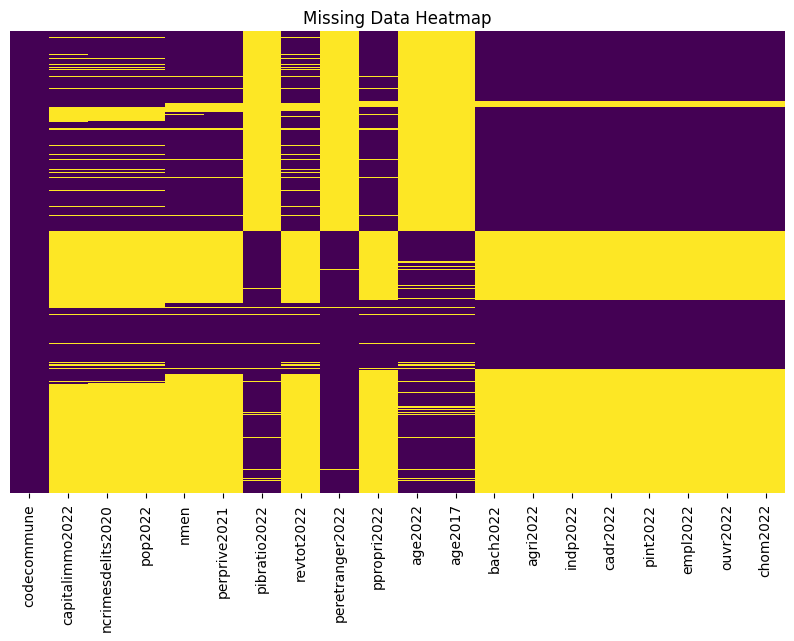

Rows with Missing Values:
      codecommune  capitalimmo2022  ncrimesdelits2020  pop2022    nmen  \
0            1001         0.000012             14.200    786.0   124.0   
1            1002         0.000002              7.155    266.0    53.0   
2            1003              NaN                NaN      NaN     NaN   
3            1004         0.000185            423.435  14201.0  3200.0   
4            1005         0.000029             20.600   1825.0   243.0   
...           ...              ...                ...      ...     ...   
66919       95676              NaN                NaN      NaN     NaN   
66920       95678              NaN                NaN      NaN     NaN   
66921       95680              NaN                NaN      NaN     NaN   
66922       95682              NaN                NaN      NaN     NaN   
66923       95690              NaN                NaN      NaN     NaN   

       perprive2021  pibratio2022  revtot2022  peretranger2022  ppropri2022  \
0     

In [84]:
# 1. Check for missing values in each column
missing_values = dataset.isnull().sum()

# 2. Create a summary DataFrame of missing values
missing_summary = missing_values[missing_values > 0].reset_index()
missing_summary.columns = ["Column", "Missing Values"]

# Display the summary of missing values
print("Summary of Missing Values:")
print(missing_summary)

# 3. Optionally, visualize missing data using a heatmap (requires seaborn)
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(merged_df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

# 1. Find rows with any missing values
rows_with_missing = merged_df[merged_df.isnull().any(axis=1)]

# 2. Display the rows with missing values
print("Rows with Missing Values:")
print(rows_with_missing)

# Optionally, you can also display a specific number of rows, e.g., the first 5 rows
print("\nFirst 5 Rows with Missing Values:")
print(rows_with_missing.head())

In [ ]:
# Remove specified columns
columns_to_remove = ["age2022", "age2017", "peretranger2022", "pibratio2022"]
dataset = dataset.drop(columns=columns_to_remove)

In [85]:
# The dataset now contains features from X and the target label 'macron_lead' from y
dataset_cleaned = dataset.dropna()

summary = dataset_cleaned.describe(include="all")
print("Summary of Cleaned Dataset:\n", summary)

Summary of Cleaned Dataset:
        codecommune  capitalimmo2022  ncrimesdelits2020        pop2022  \
count         8003     8.003000e+03        8003.000000    8003.000000   
unique        8003              NaN                NaN            NaN   
top          28167              NaN                NaN            NaN   
freq             1              NaN                NaN            NaN   
mean           NaN     2.762555e-05          51.911160    2007.315257   
std            NaN     1.703136e-04         592.858172   10398.184955   
min            NaN     1.636060e-08           0.000000       9.000000   
25%            NaN     2.114540e-06           5.070000     230.000000   
50%            NaN     5.696482e-06          10.135000     559.000000   
75%            NaN     1.781905e-05          17.405000    1485.000000   
max            NaN     7.834256e-03       32304.500000  509766.000000   

                 nmen  perprive2021  pibratio2022    revtot2022  \
count     8003.000000   800

In [86]:
X_cleaned = dataset_cleaned.drop(columns=["codecommune", "T2", "nomcommune", "nomdep"])
y_cleaned = dataset_cleaned["T2"]

# Step 4: Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.3, random_state=42
)

# Optional: Output dimensions for verification
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (5602, 19)
Testing Features Shape: (2401, 19)
Training Labels Shape: (5602,)
Testing Labels Shape: (2401,)


In [87]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_features": ["auto", "sqrt"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring="accuracy"
)

# Fit GridSearchCV
# grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
504 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

In [88]:
best_params = {
    "max_depth": 10,
    "max_features": "sqrt",
    "min_samples_leaf": 2,
    "min_samples_split": 5,
    "n_estimators": 100,
}

In [89]:
# Initialize the model with the best parameters
best_rf = RandomForestClassifier(**best_params, random_state=42)

# Fit the model
best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [90]:
# Make predictions
y_pred = best_rf.predict(X_test)

# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Feature Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print feature ranking
print("Feature ranking:")
for f in range(X_cleaned.shape[1]):
    print(
        f"{f + 1}. Feature {X_cleaned.columns[indices[f]]} ({importances[indices[f]]})"
    )

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.58      0.60      1031
           1       0.70      0.75      0.72      1370

    accuracy                           0.67      2401
   macro avg       0.67      0.66      0.66      2401
weighted avg       0.67      0.67      0.67      2401

Confusion Matrix:
[[ 594  437]
 [ 347 1023]]
Feature ranking:
1. Feature perprive2021 (0.12222305578971279)
2. Feature pibratio2022 (0.10120168515244406)
3. Feature cadr2022 (0.0852038826598646)
4. Feature ncrimesdelits2020 (0.0730535934817227)
5. Feature revtot2022 (0.06275934717500867)
6. Feature peretranger2022 (0.05654283488451579)
7. Feature pop2022 (0.04977297365459473)
8. Feature capitalimmo2022 (0.047608124830766874)
9. Feature pint2022 (0.04531248298837517)
10. Feature nmen (0.04431723644239106)
11. Feature age2017 (0.04357900902611321)
12. Feature ppropri2022 (0.04174462835529116)
13. Feature ouvr2022 (0.04020415292083285)
14. Featu

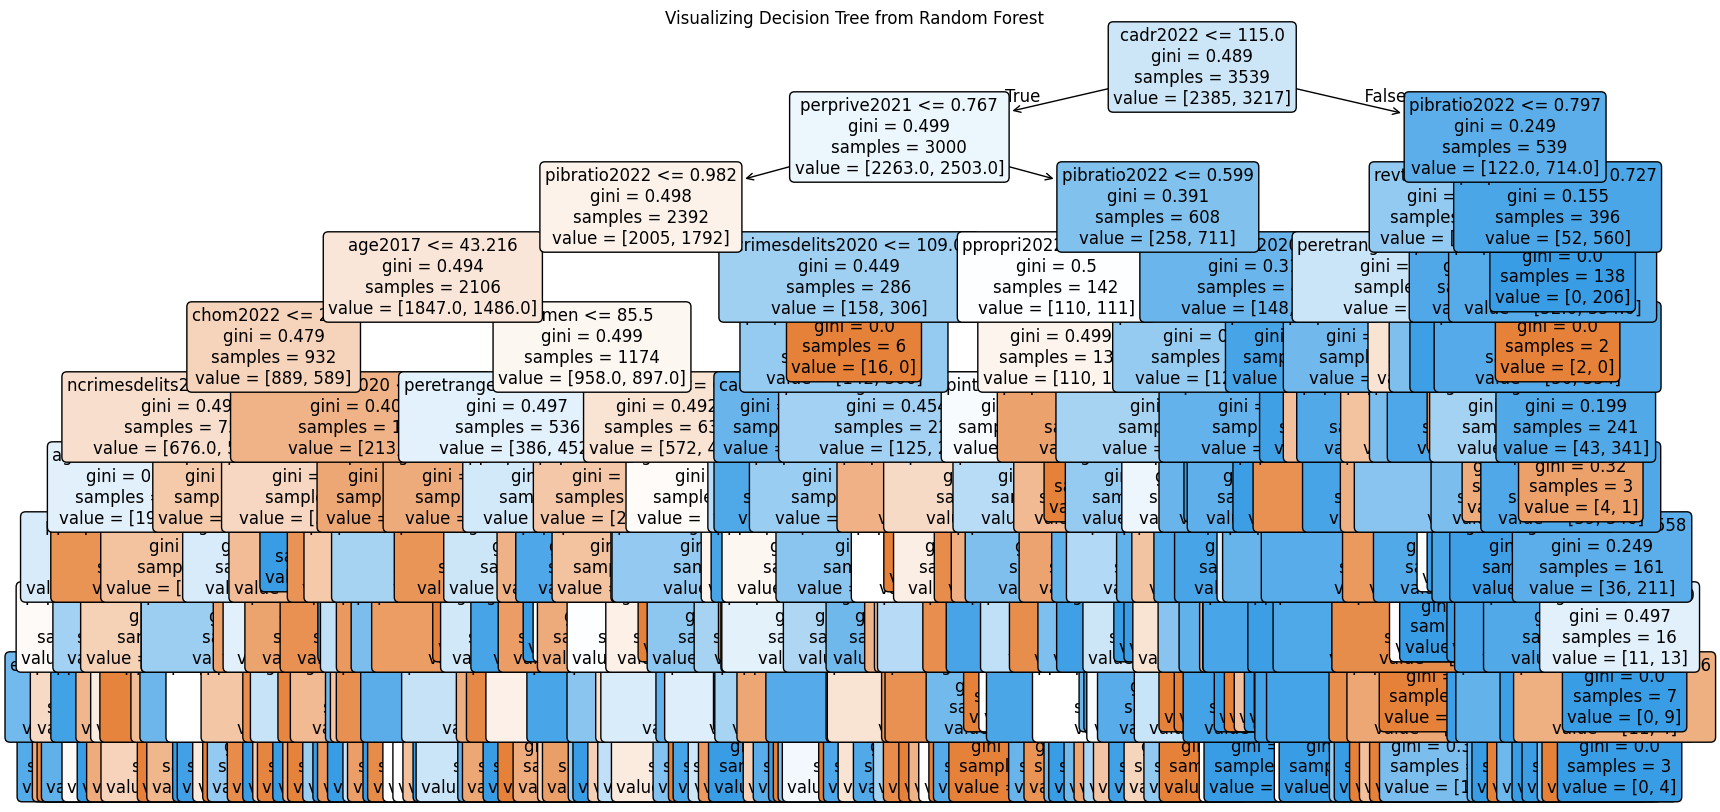

In [91]:
# Extract a single decision tree from the Random Forest model
tree = best_rf.estimators_[0]  # Change the index to visualize different trees

# Set up the figure
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(
    tree,
    filled=True,
    feature_names=X_cleaned.columns,  # Use your feature names here
    rounded=True,
    fontsize=12,
)

# Show the plot
plt.title("Visualizing Decision Tree from Random Forest")
plt.show()

In [92]:
# Fits the explainer
explainer = shap.Explainer(best_rf.predict, X_test)
# Calculates the SHAP values - It takes some time
# shap_values = explainer(X_test)
# Evaluate SHAP values
shap_values = explainer.shap_values(X_test)

PermutationExplainer explainer:  25%|██▌       | 605/2401 [01:02<03:42,  8.07it/s]


KeyboardInterrupt: 

In [ ]:
from scipy.special import softmax


def print_feature_importances_shap_values(shap_values, features):
    """
    Prints the feature importances based on SHAP values in an ordered way
    shap_values -> The SHAP values calculated from a shap.Explainer object
    features -> The name of the features, on the order presented to the explainer
    """
    # Calculates the feature importance (mean absolute shap value) for each feature
    importances = []
    for i in range(shap_values.shape[1]):
        importances.append(np.mean(np.abs(shap_values[:, i])))
    # Calculates the normalized version
    importances_norm = softmax(importances)
    # Organize the importances and columns in a dictionary
    feature_importances = {fea: imp for imp, fea in zip(importances, features)}
    feature_importances_norm = {
        fea: imp for imp, fea in zip(importances_norm, features)
    }
    # Sorts the dictionary
    feature_importances = {
        k: v
        for k, v in sorted(
            feature_importances.items(), key=lambda item: item[1], reverse=True
        )
    }
    feature_importances_norm = {
        k: v
        for k, v in sorted(
            feature_importances_norm.items(), key=lambda item: item[1], reverse=True
        )
    }
    # Prints the feature importances
    for k, v in feature_importances.items():
        print(f"{k} -> {v:.4f} (softmax = {feature_importances_norm[k]:.4f})")

In [64]:
# Dictionary mapping feature names to their full names in French
feature_names_dict = {
    "capitalimmo2022": "Capital Immobilier 2022",
    "ncrimesdelits2020": "Nombre de Crimes et Délits 2020",
    "pop2022": "Population 2022",
    "nmen": "Nombre de Ménages",
    "perprive2021": "Éducation Privée 2021",
    "revtot2022": "Revenu Total 2022",
    "ppropri2022": "Propriétaires 2022",
    "bach2022": "Baccalauréat 2022",
    "agri2022": "Agriculture 2022",
    "indp2022": "Industrie 2022",
    "cadr2022": "Cadres 2022",
    "pint2022": "Secteur Privé 2022",
    "empl2022": "Emploi 2022",
    "ouvr2022": "Travailleurs 2022",
    "chom2022": "Chômage 2022",
}

In [61]:
print_feature_importances_shap_values(shap_values, feature_names_dict)

revtot2022 -> 0.1734 (softmax = 0.0744)
perprive2021 -> 0.1293 (softmax = 0.0712)
cadr2022 -> 0.1282 (softmax = 0.0711)
capitalimmo2022 -> 0.1024 (softmax = 0.0693)
ncrimesdelits2020 -> 0.0954 (softmax = 0.0688)
ouvr2022 -> 0.0640 (softmax = 0.0667)
empl2022 -> 0.0541 (softmax = 0.0660)
bach2022 -> 0.0430 (softmax = 0.0653)
pop2022 -> 0.0380 (softmax = 0.0649)
chom2022 -> 0.0245 (softmax = 0.0641)
pint2022 -> 0.0228 (softmax = 0.0640)
ppropri2022 -> 0.0195 (softmax = 0.0638)
nmen -> 0.0193 (softmax = 0.0637)
agri2022 -> 0.0153 (softmax = 0.0635)
indp2022 -> 0.0142 (softmax = 0.0634)


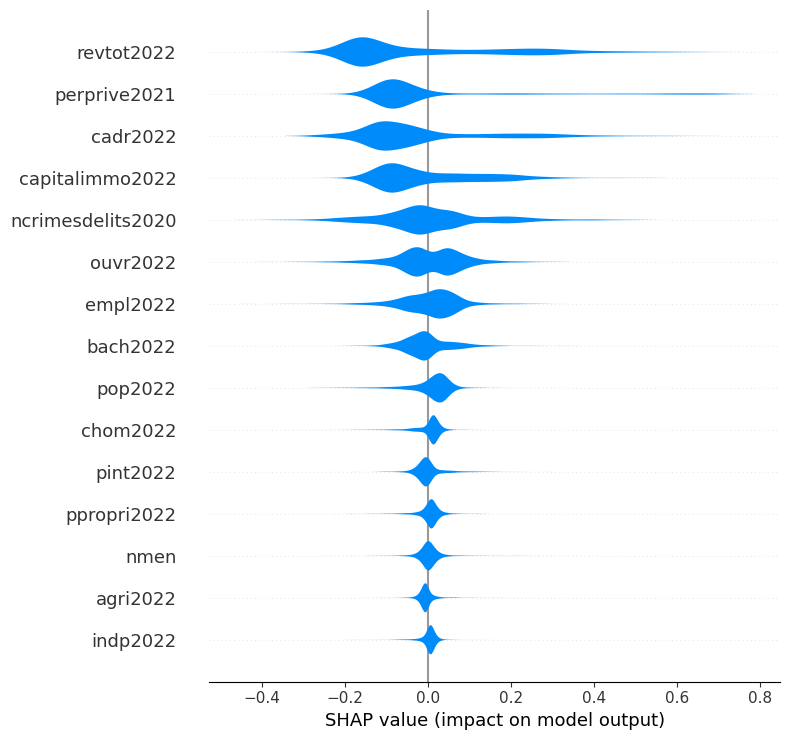

In [78]:
feature_names_list = list(feature_names_dict.keys())
shap.summary_plot(shap_values, feature_names=feature_names_list, plot_type="violin")